### What is Covariance?
***Covariance*** measures the direction in which two variables change together. If one goes up when the other goes up, covariance is positive. If one goes up when the other goes down, covariance is negative.

***Formula (population)***: Cov(X, Y) = Σ [(Xᵢ - X̄)(Yᵢ - Ȳ)] / n

For a sample, divide by (n - 1) instead of n because using the sample mean instead of the true population mean makes your spread estimate too small, and dividing by (n-1) instead of n corrects for that.

Range: −∞ to +∞ (no fixed limits). Its magnitude depends on the units of X and Y, so a covariance of 500 is meaningless without knowing what units are involved.

### What is Correlation?
***Correlation*** measures both the direction and the strength of a linear relationship between two variables, on a fixed, unit-free scale.

Range: always between −1 and +1.

* +1 → perfect positive linear relationship
* 0 → no linear relationship
* −1 → perfect negative linear relationship
* Values above 0.7 (or below -0.7) are generally called "strong," 0.3 to 0.7 "moderate," below 0.3 "weak." These are rules of thumb, not fixed laws.

***Pearson correlation coefficient(PCC)***: It means when two variables X and Y is given as the covariance divided by the product of the standard deviations of the variables
***Formula of PCC***:r = Cov(X, Y) / (σX × σY)

where σX and σY are the standard deviations of X and Y. This is just covariance, divided by the product of the two standard deviations, to remove the units.


***Spearman Rank Correlation Coefficient(SRCC)***:It is a statistical measures of the strength of a monotonic relationship between paired data. It captures the monotonicity of the variables rather than the linearnity.

***Formula of SRCC***: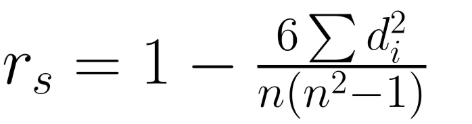




### Difference between Covariance and Correlation
| | Covariance | Correlation |
|---|---|---|
| Measures | Direction only | Direction and strength |
| Range | −∞ to +∞ | −1 to +1 |
| Units | Depends on units of X and Y | Unit-free |
| Comparable across variable pairs | No | Yes |
| Formula | Σ[(Xᵢ−X̄)(Yᵢ−Ȳ)] / n | Cov(X,Y) / (σX·σY) |

### Problem statement

Home buyers and sellers often want to know what actually drives a house's price. Is it the size, the number of bedrooms, how old it is, or how far it is from the city? Without data, this is guesswork.

This task uses a housing dataset (size, bedrooms, age, distance from city, and price) to find out how strongly each factor is linked to price. The goal is to use covariance and correlation to answer:

* Which factors move together with price, and in which direction?
* Which factors matter a lot, and which barely matter at all?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# ---------------------------------------------------------------
# 1. BUILD A SAMPLE DATASET
# ---------------------------------------------------------------
# Rules baked in on purpose, so the relationships are real and checkable:
#   - bigger size -> more bedrooms, higher price
#   - older house -> slightly lower price
#   - far from city -> lower price
np.random.seed(42)
n = 200
 
size_sqft = np.random.normal(1500, 400, n).clip(500, 3000).round()
bedrooms = (size_sqft / 500 + np.random.normal(0, 0.5, n)).round().clip(1, 6)
age_years = np.random.uniform(0, 40, n).round()
distance_km = np.random.uniform(1, 30, n).round(2)
price_lakhs = (
    size_sqft * 0.05 # each extra sqft adds 0.05 lakhs -> size becomes the biggest price driver
    + bedrooms * 5 # each bedroom adds a flat 5 lakhs -> more rooms, higher price
    - age_years * 0.8 # each year of age subtracts 0.8 lakhs -> older houses are worth less
    - distance_km * 1.2 # each km from city subtracts 1.2 lakhs -> far out from city, cheaper
    + np.random.normal(0, 8, n) # random noise (avg 0, spread 8 lakhs) -> keeps data realistic, not perfectly correlated
    + 20 # flat base price so no house prices out near zero or negative
).round()
 
df = pd.DataFrame({
    "Size_sqft": size_sqft.astype(int), # Size of a house
    "Bedrooms": bedrooms.astype(int), # how many bedrooms are in the house
    "Age_years": age_years.astype(int), # how old each house is(in years)
    "Distance_km": distance_km, # How far the house is from the city
    "Price_lakhs": price_lakhs.astype(int), # Price of a particular house
})
 
print("First 5 rows:")
print(df.head(), "\n")

First 5 rows:
   Size_sqft  Bedrooms  Age_years  Distance_km  Price_lakhs
0       1699         4         17         5.05          108
1       1445         3         11        24.06           56
2       1759         4          2         6.85          107
3       2109         5         35         5.75          121
4       1406         2         33         5.76           68 



In [31]:
df.head()

,Size_sqft,Bedrooms,Age_years,Distance_km,Price_lakhs
0,1699,4,17,5.05,108
1,1445,3,11,24.06,56
2,1759,4,2,6.85,107
3,2109,5,35,5.75,121
4,1406,2,33,5.76,68


In [32]:
df.describe()

,Size_sqft,Bedrooms,Age_years,Distance_km,Price_lakhs
count,200.000000,200.00000,200.0000,200.000000,200.00000
mean,1483.935000,3.02000,18.6750,15.081750,77.45000
std,371.714405,0.98205,11.3982,8.254336,26.89973
min,500.000000,1.00000,1.0000,1.130000,1.00000
25%,1217.750000,2.00000,8.0000,7.615000,58.00000
50%,1498.500000,3.00000,18.0000,14.410000,76.50000
75%,1700.500000,4.00000,27.2500,22.367500,96.00000
max,2588.000000,5.00000,40.0000,29.910000,148.00000


In [33]:
# 2. COVARIANCE
cov_matrix = df.cov()
print("Covariance matrix:")
print(cov_matrix.round(2), "\n")

Covariance matrix:
             Size_sqft  Bedrooms  Age_years  Distance_km  Price_lakhs
Size_sqft    138171.60    297.40     100.77      -226.16      8244.74
Bedrooms        297.40      0.96       0.29        -0.04        18.62
Age_years       100.77      0.29     129.92        -3.99       -89.40
Distance_km    -226.16     -0.04      -3.99        68.13       -93.01
Price_lakhs    8244.74     18.62     -89.40       -93.01       723.60 



In [34]:
cov_matrix.head()

,Size_sqft,Bedrooms,Age_years,Distance_km,Price_lakhs
Size_sqft,138171.598769,297.403317,100.767714,-226.164207,8244.742965
Bedrooms,297.403317,0.964422,0.287940,-0.042849,18.624121
Age_years,100.767714,0.287940,129.918970,-3.990333,-89.400754
Distance_km,-226.164207,-0.042849,-3.990333,68.134058,-93.008028
Price_lakhs,8244.742965,18.624121,-89.400754,-93.008028,723.595477


In [35]:
# 3. CORRELATION
corr_matrix = df.corr()
print("Correlation matrix:")
print(corr_matrix.round(2), "\n")

Correlation matrix:
             Size_sqft  Bedrooms  Age_years  Distance_km  Price_lakhs
Size_sqft         1.00      0.81       0.02        -0.07         0.82
Bedrooms          0.81      1.00       0.03        -0.01         0.71
Age_years         0.02      0.03       1.00        -0.04        -0.29
Distance_km      -0.07     -0.01      -0.04         1.00        -0.42
Price_lakhs       0.82      0.71      -0.29        -0.42         1.00 



In [36]:
corr_matrix.head()

,Size_sqft,Bedrooms,Age_years,Distance_km,Price_lakhs
Size_sqft,1.000000,0.814710,0.023783,-0.073711,0.824555
Bedrooms,0.814710,1.000000,0.025724,-0.005286,0.705008
Age_years,0.023783,0.025724,1.000000,-0.042412,-0.291579
Distance_km,-0.073711,-0.005286,-0.042412,1.000000,-0.418881
Price_lakhs,0.824555,0.705008,-0.291579,-0.418881,1.000000


In [37]:
# 4. FIND THE STRONGEST RELATIONSHIPS
# Pull every pair out, sort by strength (ignore self-correlation of 1.0)
pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)
print("Strongest relationships (by absolute correlation):")
print(pairs.round(2), "\n")

Strongest relationships (by absolute correlation):
Size_sqft    Price_lakhs    0.82
             Bedrooms       0.81
Bedrooms     Price_lakhs    0.71
Distance_km  Price_lakhs   -0.42
Age_years    Price_lakhs   -0.29
Size_sqft    Distance_km   -0.07
Age_years    Distance_km   -0.04
Bedrooms     Age_years      0.03
Size_sqft    Age_years      0.02
Bedrooms     Distance_km   -0.01
dtype: float64 



In [38]:
pairs

Size_sqft    Price_lakhs    0.824555
             Bedrooms       0.814710
Bedrooms     Price_lakhs    0.705008
Distance_km  Price_lakhs   -0.418881
Age_years    Price_lakhs   -0.291579
Size_sqft    Distance_km   -0.073711
Age_years    Distance_km   -0.042412
Bedrooms     Age_years      0.025724
Size_sqft    Age_years      0.023783
Bedrooms     Distance_km   -0.005286
dtype: float64

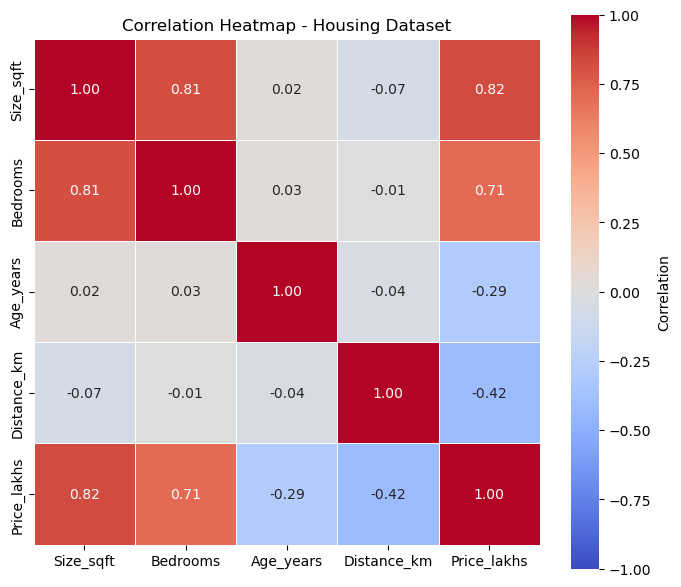

In [40]:
# 5. CORRELATION HEATMAP
plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"label": "Correlation"},
)
plt.title("Correlation Heatmap - Housing Dataset")
plt.tight_layout()

### Which factors move together with price, and in which direction?

* Size (0.82) moves together with price and it is strong positive.If the house size is bigger in size then the price goes towards higher side.
* Bedrooms (0.71) also moves together with price and also a strong positive. if more bedrooms are in the house, the price goes towards higher side.
* Distance from city (-0.42) moves opposite and it is negative side as well. If the house is far away from city then the price goes towards lower side.
* Age (-0.29) moves opposite and it is sightly on a negative side. If the house has been built for a long time then the price of it goes slightly towards the lower side but it also depends on the condition of house, whether it is in the city or outside of the city, if it is outside from the city then how far it is and other external factors as well.

### Which factors matter a lot, and which barely matter at all?

* Matters a lot: Size (0.82) and Bedrooms (0.71). Both are strong drivers of price.
* Matters somewhat: Distance (-0.42). Worth factoring in, but not decisive on its own.
* Matters a little: Age (-0.29). A minor pull on price, easy to be outweighed by size or location.
* Barely matters: Bedrooms vs Distance (-0.01) and most of the non-price pairs sit near 0.00, meaning those factors don't explain each other at all.